In [1]:
!git config --global user.name "bootankr1"
!git config --global user.email "bco010115@gmail.com"

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
%cd "/content/drive/MyDrive/paper1-reproduction-2022-2"

/content/drive/MyDrive/paper1-reproduction-2022-2


In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [5]:
DATA_PATH = "/content/drive/MyDrive/paper1-reproduction-2022-2/data/raw/heat_Data.csv"

df = pd.read_csv(
    DATA_PATH,
    encoding="cp949",
    low_memory=False
)

print("전체 shape:", df.shape)
print(df.columns.tolist())

df.head()

전체 shape: (103913, 11)
['일자', '시간', '생산항목코드', '열공급시설ID', '난방지역ID', '공급유량', '공급열량', '공급압력', '공급온도', '회수압력', '회수온도']


,일자,시간,생산항목코드,열공급시설ID,난방지역ID,공급유량,공급열량,공급압력,공급온도,회수압력,회수온도
0,2023-07-07,1,열,중앙열공급시설,여의도,52,2,5,84,3,57
1,2023-07-07,1,열,강남열공급시설,송파/잠실,0,56,0,0,0,0
2,2023-07-07,1,열,수서열공급시설,강남/서초,0,6,0,0,0,0
3,2023-07-07,1,열,동남권열공급시설,동남권,0,0,0,0,0,0
4,2023-07-07,1,열,상암열공급시설,상암,99,6,3,96,2,44


In [9]:
!git status
!git remote -v

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	data/

nothing added to commit but untracked files present (use "git add" to track)
origin	https://github.com/bootankr1/paper1-reproduction-2022-2.git (fetch)
origin	https://github.com/bootankr1/paper1-reproduction-2022-2.git (push)


In [10]:
sangam = df[
    (df["열공급시설ID"] == "상암열공급시설") &
    (df["난방지역ID"] == "상암")
].copy()

print("상암 shape:", sangam.shape)

sangam.head()

상암 shape: (4497, 11)


,일자,시간,생산항목코드,열공급시설ID,난방지역ID,공급유량,공급열량,공급압력,공급온도,회수압력,회수온도
4,2023-07-07,1,열,상암열공급시설,상암,99,6,3,96,2,44
25,2023-07-07,2,열,상암열공급시설,상암,85,4,3,97,2,44
46,2023-07-07,3,열,상암열공급시설,상암,79,4,3,96,2,42
67,2023-07-07,4,열,상암열공급시설,상암,93,5,3,96,1,41
88,2023-07-07,5,열,상암열공급시설,상암,108,5,3,96,2,42


In [11]:
sangam = sangam.rename(columns={
    "일자": "date",
    "시간": "hour_raw",
    "공급유량": "flow",
    "공급열량": "heat",
    "공급압력": "supply_pressure",
    "공급온도": "supply_temp",
    "회수압력": "return_pressure",
    "회수온도": "return_temp"
})

In [12]:
sangam["datetime"] = (
    pd.to_datetime(sangam["date"])
    + pd.to_timedelta(
        sangam["hour_raw"] - 1,
        unit="h"
    )
)

sangam = (
    sangam
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("시작:", sangam["datetime"].min())
print("끝:", sangam["datetime"].max())
print("시점 수:", sangam["datetime"].nunique())

시작: 2023-01-01 00:00:00
끝: 2023-07-07 08:00:00
시점 수: 4497


In [13]:
numeric_cols = [
    "flow",
    "heat",
    "supply_pressure",
    "supply_temp",
    "return_pressure",
    "return_temp"
]

for col in numeric_cols:
    sangam[col] = pd.to_numeric(
        sangam[col],
        errors="coerce"
    )

print(sangam[numeric_cols].isna().sum())

flow               121
heat                10
supply_pressure      0
supply_temp        119
return_pressure      0
return_temp          0
dtype: int64


In [14]:
heat_median = sangam["heat"].median()

heat_mad = (
    sangam["heat"] - heat_median
).abs().median()

lower = heat_median - 10 * heat_mad
upper = heat_median + 10 * heat_mad

heat_outlier_mask = (
    (sangam["heat"] < lower) |
    (sangam["heat"] > upper)
)

print("Heat median:", heat_median)
print("Heat MAD:", heat_mad)
print("Outlier 수:", heat_outlier_mask.sum())

print(
    sangam.loc[
        heat_outlier_mask,
        ["datetime", "heat"]
    ]
)

sangam.loc[
    heat_outlier_mask,
    "heat"
] = np.nan

Heat median: 23.0
Heat MAD: 12.0
Outlier 수: 1
                datetime      heat
1641 2023-03-10 09:00:00  931865.0


In [15]:
sangam[numeric_cols] = (
    sangam[numeric_cols]
    .interpolate(
        method="linear",
        limit_direction="both"
    )
)

print(sangam[numeric_cols].isna().sum())

flow               0
heat               0
supply_pressure    0
supply_temp        0
return_pressure    0
return_temp        0
dtype: int64


In [16]:
baseline_df = sangam[
    [
        "datetime",
        "flow",
        "heat",
        "supply_pressure",
        "supply_temp",
        "return_pressure",
        "return_temp"
    ]
].copy()

baseline_df.info()

baseline_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4497 entries, 0 to 4496
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         4497 non-null   datetime64[ns]
 1   flow             4497 non-null   float64       
 2   heat             4497 non-null   float64       
 3   supply_pressure  4497 non-null   int64         
 4   supply_temp      4497 non-null   float64       
 5   return_pressure  4497 non-null   int64         
 6   return_temp      4497 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(3)
memory usage: 246.1 KB


,datetime,flow,heat,supply_pressure,supply_temp,return_pressure,return_temp
0,2023-01-01 00:00:00,1244.0,60.0,5,96.0,2,45
1,2023-01-01 01:00:00,1219.0,62.0,5,96.0,2,46
2,2023-01-01 02:00:00,1177.0,60.0,5,95.0,2,47
3,2023-01-01 03:00:00,1182.0,56.0,5,95.0,2,48
4,2023-01-01 04:00:00,1188.0,53.0,5,95.0,2,49


In [17]:
p1_df = baseline_df.copy()

p1_df["year"] = p1_df["datetime"].dt.year
p1_df["month"] = p1_df["datetime"].dt.month
p1_df["day"] = p1_df["datetime"].dt.day
p1_df["hour"] = p1_df["datetime"].dt.hour

In [18]:
p1_df["e_diff"] = p1_df["heat"].diff()

p1_df["e_diff"] = (
    p1_df["e_diff"]
    .fillna(1e-6)
)

In [19]:
P1_FEATURE_COLS = [
    "year",
    "month",
    "day",
    "hour",

    "e_diff",

    "flow",
    "supply_pressure",
    "supply_temp",
    "return_pressure",
    "return_temp"
]

P1_TARGET_COL = "heat"

print("Feature 개수:", len(P1_FEATURE_COLS))
print(P1_FEATURE_COLS)

Feature 개수: 10
['year', 'month', 'day', 'hour', 'e_diff', 'flow', 'supply_pressure', 'supply_temp', 'return_pressure', 'return_temp']


In [20]:
EPS = 1e-6

p1_df[P1_FEATURE_COLS] = (
    p1_df[P1_FEATURE_COLS]
    .replace(0, EPS)
)

In [21]:
P1_FORECAST_HORIZON = 24
P1_LOOKBACK = 24

In [22]:
def create_paper1_windows(
    df,
    feature_cols,
    target_col,
    lookback,
    horizon=24
):
    features = df[
        feature_cols
    ].to_numpy(dtype=np.float32)

    target = df[
        target_col
    ].to_numpy(dtype=np.float32)

    X = []
    y = []

    for end_idx in range(
        lookback,
        len(df) - horizon + 1
    ):
        start_idx = end_idx - lookback

        X.append(
            features[start_idx:end_idx]
        )

        y.append(
            target[
                end_idx:end_idx + horizon
            ]
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32)
    )

In [23]:
p1_X_raw, p1_y_raw = create_paper1_windows(
    df=p1_df,
    feature_cols=P1_FEATURE_COLS,
    target_col=P1_TARGET_COL,
    lookback=P1_LOOKBACK,
    horizon=P1_FORECAST_HORIZON
)

print("X:", p1_X_raw.shape)
print("y:", p1_y_raw.shape)

X: (4450, 24, 10)
y: (4450, 24)


In [24]:
assert len(p1_X_raw) == len(p1_y_raw)

print(
    "Cardinality OK:",
    len(p1_X_raw)
)

Cardinality OK: 4450


In [25]:
(
    p1_X_train_raw,
    p1_X_temp_raw,
    p1_y_train_raw,
    p1_y_temp_raw
) = train_test_split(
    p1_X_raw,
    p1_y_raw,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

(
    p1_X_val_raw,
    p1_X_test_raw,
    p1_y_val_raw,
    p1_y_test_raw
) = train_test_split(
    p1_X_temp_raw,
    p1_y_temp_raw,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

In [26]:
print(
    "Train:",
    p1_X_train_raw.shape,
    p1_y_train_raw.shape
)

print(
    "Val:",
    p1_X_val_raw.shape,
    p1_y_val_raw.shape
)

print(
    "Test:",
    p1_X_test_raw.shape,
    p1_y_test_raw.shape
)

Train: (3560, 24, 10) (3560, 24)
Val: (445, 24, 10) (445, 24)
Test: (445, 24, 10) (445, 24)


In [27]:
assert len(p1_X_train_raw) == len(p1_y_train_raw)
assert len(p1_X_val_raw) == len(p1_y_val_raw)
assert len(p1_X_test_raw) == len(p1_y_test_raw)

print("Split cardinality OK")

Split cardinality OK


In [28]:
p1_x_scaler = MinMaxScaler(
    feature_range=(0, 1)
)

p1_y_scaler = MinMaxScaler(
    feature_range=(0, 1)
)

p1_n_features = len(P1_FEATURE_COLS)

In [29]:
p1_x_scaler.fit(
    p1_X_train_raw.reshape(
        -1,
        p1_n_features
    )
)

MinMaxScaler()

In [30]:
p1_X_train = p1_x_scaler.transform(
    p1_X_train_raw.reshape(
        -1,
        p1_n_features
    )
).reshape(
    p1_X_train_raw.shape
)

p1_X_val = p1_x_scaler.transform(
    p1_X_val_raw.reshape(
        -1,
        p1_n_features
    )
).reshape(
    p1_X_val_raw.shape
)

p1_X_test = p1_x_scaler.transform(
    p1_X_test_raw.reshape(
        -1,
        p1_n_features
    )
).reshape(
    p1_X_test_raw.shape
)

In [31]:
p1_y_scaler.fit(
    p1_y_train_raw.reshape(-1, 1)
)

p1_y_train = p1_y_scaler.transform(
    p1_y_train_raw.reshape(-1, 1)
).reshape(
    p1_y_train_raw.shape
)

p1_y_val = p1_y_scaler.transform(
    p1_y_val_raw.reshape(-1, 1)
).reshape(
    p1_y_val_raw.shape
)

p1_y_test = p1_y_scaler.transform(
    p1_y_test_raw.reshape(-1, 1)
).reshape(
    p1_y_test_raw.shape
)

In [32]:
print("===== TRAIN =====")
print("X:", p1_X_train.shape)
print("y:", p1_y_train.shape)

print("\n===== VAL =====")
print("X:", p1_X_val.shape)
print("y:", p1_y_val.shape)

print("\n===== TEST =====")
print("X:", p1_X_test.shape)
print("y:", p1_y_test.shape)

===== TRAIN =====
X: (3560, 24, 10)
y: (3560, 24)

===== VAL =====
X: (445, 24, 10)
y: (445, 24)

===== TEST =====
X: (445, 24, 10)
y: (445, 24)


In [33]:
assert p1_X_train.shape[0] == p1_y_train.shape[0]
assert p1_X_val.shape[0] == p1_y_val.shape[0]
assert p1_X_test.shape[0] == p1_y_test.shape[0]

assert p1_X_train.shape[1] == 24
assert p1_y_train.shape[1] == 24

print("Everything OK")

Everything OK


In [34]:
tf.keras.backend.clear_session()

def build_paper1_lstm(
    lookback,
    n_features,
    horizon=24
):
    model = Sequential([
        Input(
            shape=(
                lookback,
                n_features
            )
        ),

        LSTM(
            128,
            activation="tanh",
            return_sequences=True
        ),

        LSTM(
            128,
            activation="tanh"
        ),

        Dense(
            horizon,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [52]:
p1_model = build_paper1_lstm(
    lookback=P1_LOOKBACK,
    n_features=p1_n_features,
    horizon=P1_FORECAST_HORIZON
)

p1_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,848 (804.09 KB)

 Trainable params: 205,848 (804.09 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
print(
    p1_X_train.shape,
    p1_y_train.shape
)

print(
    p1_X_val.shape,
    p1_y_val.shape
)

assert len(p1_X_train) == len(p1_y_train)
assert len(p1_X_val) == len(p1_y_val)

(3560, 24, 10) (3560, 24)
(445, 24, 10) (445, 24)


In [54]:
print(
    p1_X_train.shape,
    p1_y_train.shape
)

print(
    p1_X_val.shape,
    p1_y_val.shape
)

assert len(p1_X_train) == len(p1_y_train)
assert len(p1_X_val) == len(p1_y_val)

(3560, 24, 10) (3560, 24)
(445, 24, 10) (445, 24)


In [55]:
p1_history = p1_model.fit(
    p1_X_train,
    p1_y_train,

    validation_data=(
        p1_X_val,
        p1_y_val
    ),

    epochs=30,
    batch_size=16,

    verbose=1
)

Epoch 1/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - loss: 0.0108 - val_loss: 0.0051
Epoch 2/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0049 - val_loss: 0.0050
Epoch 3/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - loss: 0.0047 - val_loss: 0.0047
Epoch 4/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.0042 - val_loss: 0.0035
Epoch 5/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 6/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 7/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 8/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 9/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 0.0021 - val_loss: 0.0022
Epoch 10/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 11/30
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 12/30
223/223 ━━━━━━━━━━━━━

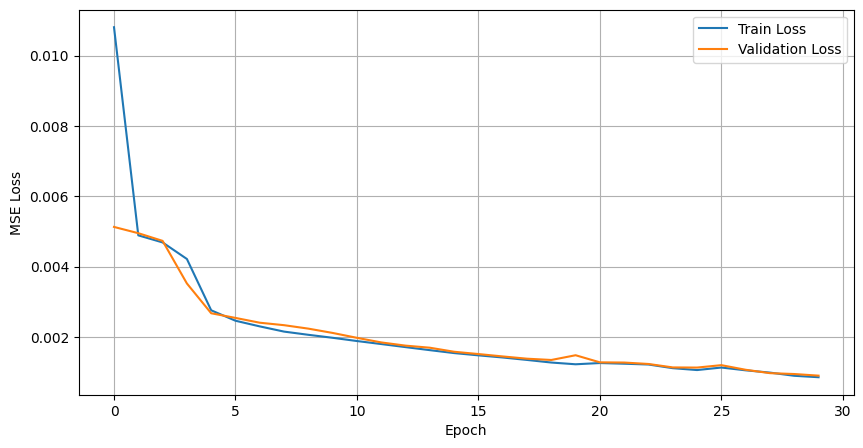

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    p1_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    p1_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid()

plt.show()

In [57]:
p1_y_pred_scaled = p1_model.predict(
    p1_X_test
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


In [58]:
p1_y_pred = p1_y_scaler.inverse_transform(
    p1_y_pred_scaled.reshape(-1, 1)
).reshape(
    p1_y_pred_scaled.shape
)

p1_y_true = p1_y_scaler.inverse_transform(
    p1_y_test.reshape(-1, 1)
).reshape(
    p1_y_test.shape
)

In [59]:
p1_true_flat = p1_y_true.flatten()
p1_pred_flat = p1_y_pred.flatten()

p1_r2 = r2_score(
    p1_true_flat,
    p1_pred_flat
)

p1_mae = mean_absolute_error(
    p1_true_flat,
    p1_pred_flat
)

p1_mse = mean_squared_error(
    p1_true_flat,
    p1_pred_flat
)

print("===== Paper 1 — 1 Day Model =====")
print(f"R²  : {p1_r2:.4f}")
print(f"MAE : {p1_mae:.4f}")
print(f"MSE : {p1_mse:.4f}")

===== Paper 1 — 1 Day Model =====
R²  : 0.9794
MAE : 2.4684
MSE : 12.5930


In [60]:
paper1_results = pd.DataFrame([
    {
        "lookback_days": 1,
        "lookback_hours": 24,
        "R2": p1_r2,
        "MAE": p1_mae,
        "MSE": p1_mse
    }
])

paper1_results

,lookback_days,lookback_hours,R2,MAE,MSE
0,1,24,0.979398,2.468384,12.592985


In [61]:
!pip install -q shap

In [62]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [64]:
SHAP_SEED = 42

rng = np.random.default_rng(SHAP_SEED)

background_size = min(100, len(p1_X_train))
explain_size = min(100, len(p1_X_test))

background_idx = rng.choice(
    len(p1_X_train),
    size=background_size,
    replace=False
)

explain_idx = rng.choice(
    len(p1_X_test),
    size=explain_size,
    replace=False
)

X_background =p1_X_train[background_idx]
X_explain = p1_X_test[explain_idx]

print("Background:", X_background.shape)
print("Explain   :", X_explain.shape)

Background: (100, 24, 10)
Explain   : (100, 24, 10)


In [66]:
explainer = shap.GradientExplainer(
    p1_model,
    X_background
)

shap_values_raw = explainer.shap_values(
    X_explain
)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_4
Received: inputs=['Tensor(shape=(100, 24, 10))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_4
Received: inputs=['Tensor(shape=(50, 24, 10))']
  warnings.warn(msg)


In [67]:
def normalize_shap_output(shap_values):

    # 최신 SHAP Explanation 객체
    if hasattr(shap_values, "values"):
        arr = np.asarray(shap_values.values)

    # 구버전: 출력별 list
    elif isinstance(shap_values, list):
        arr = np.stack(
            [np.asarray(v) for v in shap_values],
            axis=-1
        )

    else:
        arr = np.asarray(shap_values)

    # 단일 출력일 경우 output 축 추가
    if arr.ndim == 3:
        arr = arr[..., np.newaxis]

    if arr.ndim != 4:
        raise ValueError(
            f"Unexpected SHAP shape: {arr.shape}"
        )

    return arr


shap_values = normalize_shap_output(
    shap_values_raw
)

print("Final SHAP shape:", shap_values.shape)

Final SHAP shape: (100, 24, 10, 24)


In [68]:
feature_importance = np.mean(
    np.abs(shap_values),
    axis=(0, 1, 3)
)

print(feature_importance.shape)

(10,)


In [71]:
shap_importance_df = pd.DataFrame({
    "feature":P1_FEATURE_COLS,
    "mean_abs_shap": feature_importance
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance_df["rank"] = (
    np.arange(1, len(shap_importance_df) + 1)
)

shap_importance_df["importance_percent"] = (
    shap_importance_df["mean_abs_shap"]
    /
    shap_importance_df["mean_abs_shap"].sum()
    * 100
)

shap_importance_df

,feature,mean_abs_shap,rank,importance_percent
0,flow,0.006431,1,37.428007
1,month,0.004122,2,23.988673
2,hour,0.002481,3,14.438668
3,supply_pressure,0.001039,4,6.047289
4,e_diff,0.000911,5,5.301179
5,day,0.000902,6,5.251791
6,return_pressure,0.000876,7,5.097407
7,return_temp,0.000321,8,1.871017
8,supply_temp,0.000099,9,0.575969
9,year,0.000000,10,0.000000


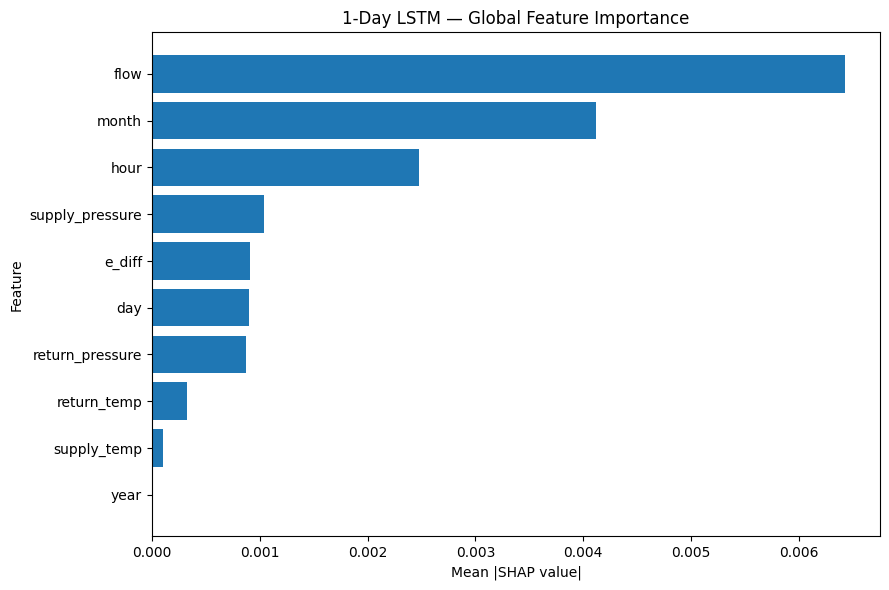

In [72]:
plot_df = shap_importance_df.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["feature"],
    plot_df["mean_abs_shap"]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(
    "1-Day LSTM — Global Feature Importance"
)

plt.tight_layout()
plt.show()

In [73]:
time_feature_importance = np.mean(
    np.abs(shap_values),
    axis=(0, 3)
)

print(time_feature_importance.shape)

(24, 10)


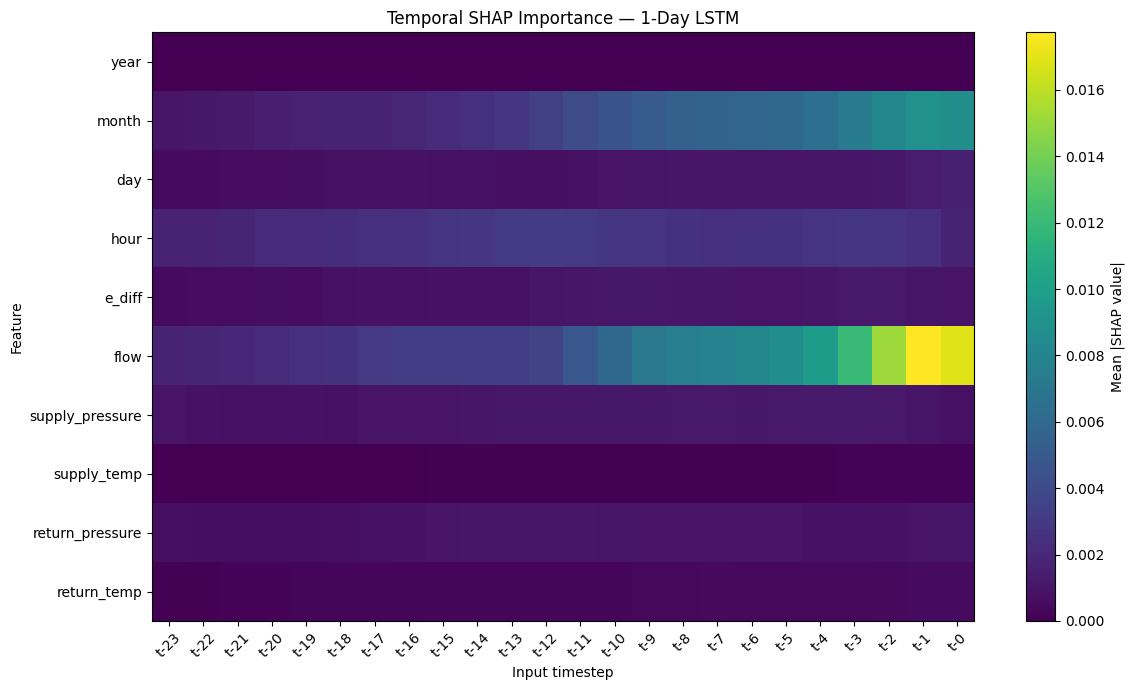

In [74]:
plt.figure(figsize=(12, 7))

plt.imshow(
    time_feature_importance.T,
    aspect="auto"
)

plt.colorbar(
    label="Mean |SHAP value|"
)

plt.yticks(
    np.arange(len(P1_FEATURE_COLS)),
    P1_FEATURE_COLS
)

plt.xticks(
    np.arange(24),
    [f"t-{23-i}" for i in range(24)],
    rotation=45
)

plt.xlabel("Input timestep")
plt.ylabel("Feature")

plt.title(
    "Temporal SHAP Importance — 1-Day LSTM"
)

plt.tight_layout()
plt.show()

In [75]:
RESULT_DIR ="/content/drive/MyDrive/paper1-reproduction-2022-2/results/random_split"

SHAP_RESULT_DIR = (
    f"{RESULT_DIR}/shap"
)

os.makedirs(
    SHAP_RESULT_DIR,
    exist_ok=True
)

shap_importance_df.to_csv(
    f"{SHAP_RESULT_DIR}/1day_feature_importance.csv",
    index=False
)

np.save(
    f"{SHAP_RESULT_DIR}/1day_shap_values.npy",
    shap_values
)

print("SHAP results saved.")

SHAP results saved.
